In [6]:
import torch

print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA disponible : True
GPU : Tesla T4


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!pip install -q torchinfo pycocotools tqdm seaborn

In [9]:
!mkdir -p /content/data
%cd /content/data

!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

/content/data


In [10]:
import os

print(os.path.exists("/content/data/images"))
print(os.path.exists("/content/data/annotations"))

True
True


In [11]:
import torch
import torchvision
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import matplotlib

In [12]:
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='train', img_size=256):
        self.root = root
        self.img_size = img_size
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                interpolation=transforms.InterpolationMode.NEAREST),
        ])
        list_file = os.path.join(root, 'annotations',
            'trainval.txt' if split=='train' else 'test.txt')
        with open(list_file) as f:
            self.names = [line.split()[0] for line in f.readlines()]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, 'images',
            self.names[idx]+'.jpg')).convert('RGB')
        mask = Image.open(os.path.join(self.root, 'annotations', 'trimaps',
            self.names[idx]+'.png'))
        img = self.img_transform(img)
        mask = torch.tensor(np.array(self.mask_transform(mask)),
            dtype=torch.long) - 1
        return img, mask

In [13]:
import os
os.makedirs('/content/drive/MyDrive/TP_DL', exist_ok=True)
print("Dossier cree :", os.path.exists('/content/drive/MyDrive/TP_DL'))

Dossier cree : True


Trainval : 3680 images
Test     : 3669 images


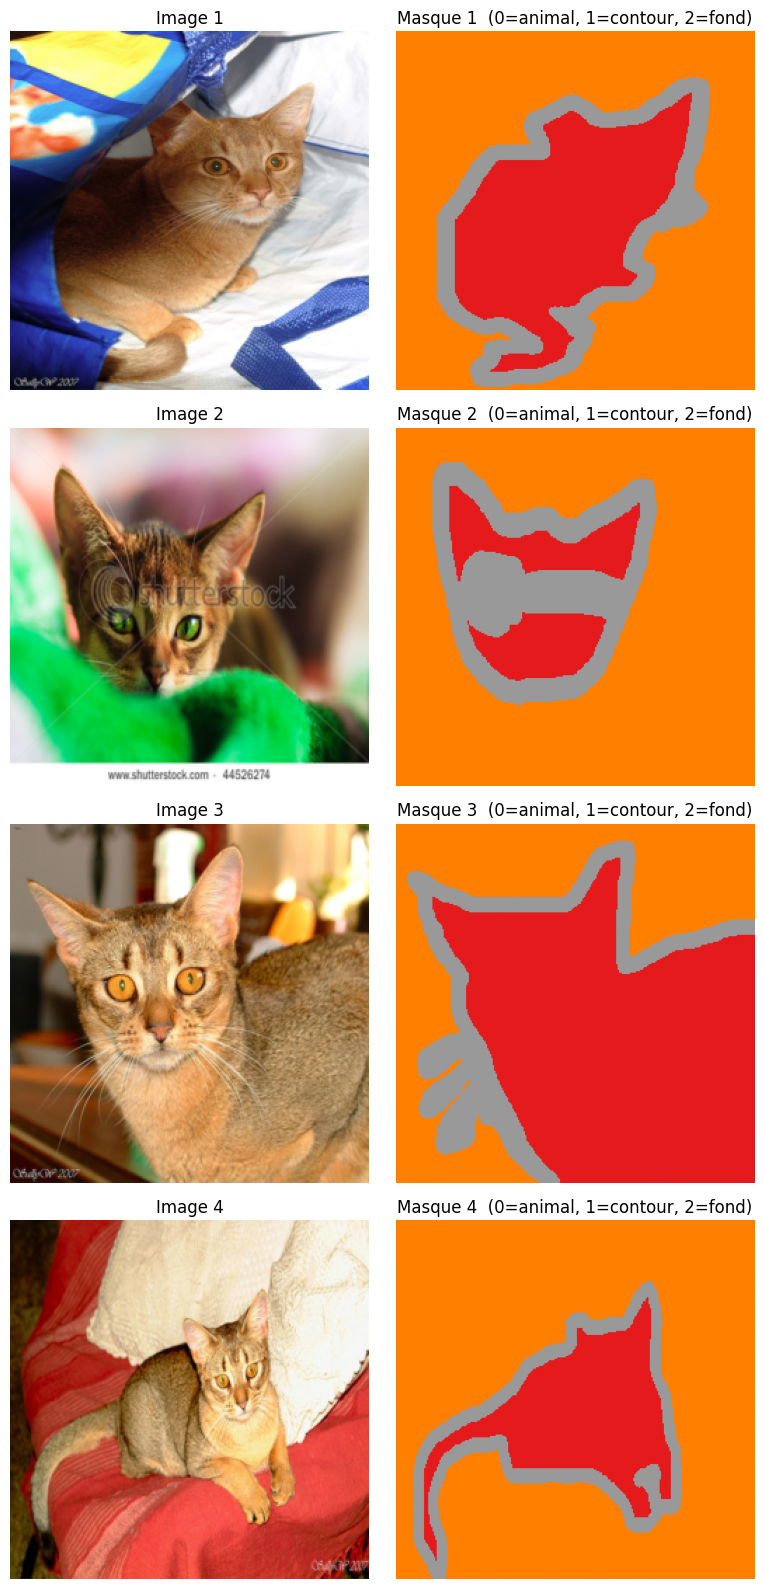

In [14]:
root = '/content/data'

full_train = PetSegmentationDataset(root, split='train', img_size=256)
test_ds    = PetSegmentationDataset(root, split='test',  img_size=256)
print(f"Trainval : {len(full_train)} images")
print(f"Test     : {len(test_ds)} images")

# Afficher 4 exemples
fig, axes = plt.subplots(4, 2, figsize=(8, 16))
cmap = matplotlib.colormaps.get_cmap('Set1').resampled(3)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for i in range(4):
    img, mask = full_train[i]
    img_display = (img * std + mean).clamp(0,1).permute(1,2,0).numpy()

    axes[i,0].imshow(img_display)
    axes[i,0].set_title(f'Image {i+1}')
    axes[i,0].axis('off')

    axes[i,1].imshow(mask.numpy(), cmap=cmap, vmin=0, vmax=2)
    axes[i,1].set_title(f'Masque {i+1}  (0=animal, 1=contour, 2=fond)')
    axes[i,1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/exemples_dataset.png', dpi=150)
plt.show()

Distribution des classes :
  Animal (0) : 26.8%
  Contour (1) : 60.5%
  Fond (2) : 12.7%


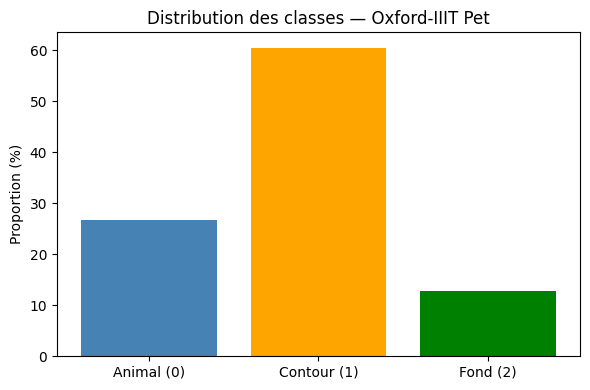


Poids par classe : tensor([1.2454, 0.5507, 2.6225])


In [15]:
from collections import defaultdict

counts = defaultdict(int)
for i in range(min(200, len(full_train))):
    _, mask = full_train[i]
    for cls in range(3):
        counts[cls] += (mask == cls).sum().item()

total  = sum(counts.values())
labels = ['Animal (0)', 'Contour (1)', 'Fond (2)']

print("Distribution des classes :")
for cls in range(3):
    pct = 100 * counts[cls] / total
    print(f"  {labels[cls]} : {pct:.1f}%")

plt.figure(figsize=(6,4))
plt.bar(labels, [100*counts[c]/total for c in range(3)],
        color=['steelblue','orange','green'])
plt.ylabel('Proportion (%)')
plt.title('Distribution des classes — Oxford-IIIT Pet')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/distribution_classes.png', dpi=150)
plt.show()

# Poids pour CrossEntropyLoss
freqs   = torch.tensor([counts[c] for c in range(3)], dtype=torch.float)
weights = freqs.sum() / (3 * freqs)
print(f"\nPoids par classe : {weights}")


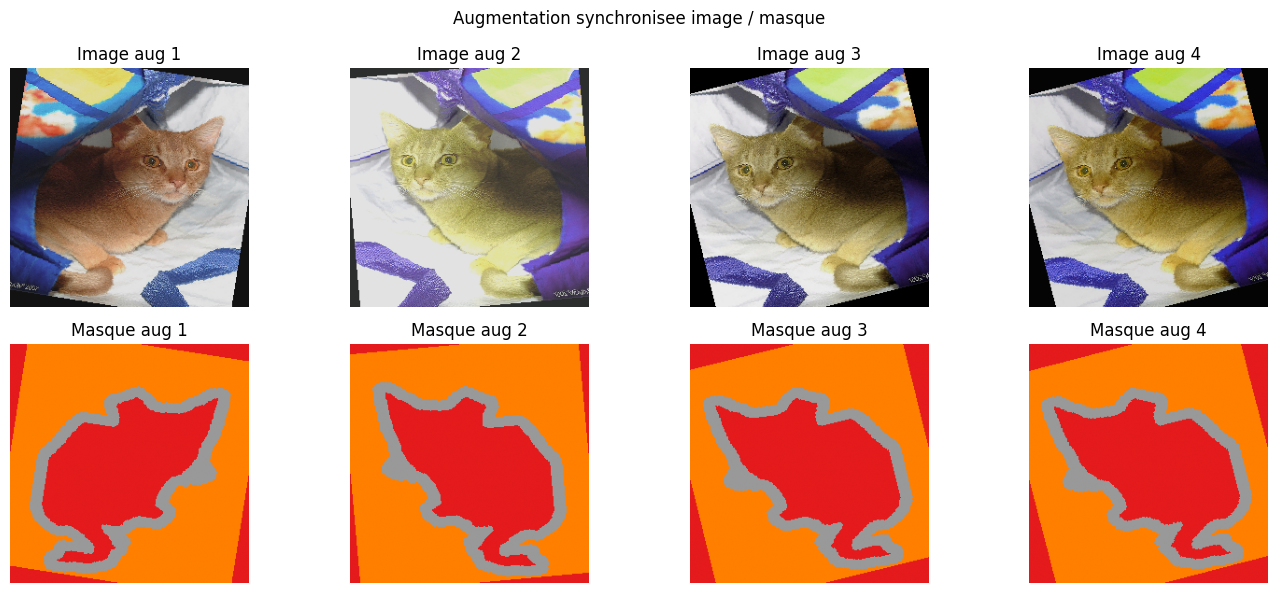

In [16]:
import torchvision.transforms.v2 as T

def augment(img_pil, mask_pil, img_size=256):
    """
    img_pil  : PIL Image RGB
    mask_pil : PIL Image (valeurs 1/2/3)
    Retourne : (img_tensor normalise, mask_tensor classes 0/1/2)
    """
    # Transformations geometriques identiques sur image ET masque
    joint = T.Compose([
        T.Resize((img_size, img_size),
                 interpolation=T.InterpolationMode.NEAREST),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=15,
                         interpolation=T.InterpolationMode.NEAREST),
    ])
    img_pil, mask_pil = joint(img_pil, mask_pil)

    # Color jitter sur l'image seulement
    img_pil = T.ColorJitter(brightness=0.3, contrast=0.3,
                             saturation=0.2, hue=0.1)(img_pil)

    img_tensor  = T.Normalize([0.485,0.456,0.406],
                               [0.229,0.224,0.225])(T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])(img_pil)
)
    mask_tensor = torch.tensor(np.array(mask_pil), dtype=torch.long) - 1
    return img_tensor, mask_tensor


# Afficher 4 variantes d'augmentation sur la meme image
sample_name = full_train.names[0]
img_pil  = Image.open(os.path.join(root,'images',
                                    sample_name+'.jpg')).convert('RGB')
mask_pil = Image.open(os.path.join(root,'annotations','trimaps',
                                    sample_name+'.png'))

fig, axes = plt.subplots(2, 4, figsize=(14,6))
cmap = matplotlib.colormaps.get_cmap('Set1').resampled(3)
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

for col in range(4):
    img_aug, mask_aug = augment(img_pil, mask_pil)
    img_display = (img_aug * std + mean).clamp(0,1).permute(1,2,0).numpy()

    axes[0,col].imshow(img_display)
    axes[0,col].set_title(f'Image aug {col+1}')
    axes[0,col].axis('off')

    axes[1,col].imshow(mask_aug.numpy(), cmap=cmap, vmin=0, vmax=2)
    axes[1,col].set_title(f'Masque aug {col+1}')
    axes[1,col].axis('off')

plt.suptitle('Augmentation synchronisee image / masque')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/augmentation.png', dpi=150)
plt.show()

In [17]:
from torch.utils.data import random_split, DataLoader

torch.manual_seed(42)

# SPLIT 70% TRAIN / 15% VAL / 15% TEST

N = len(full_train)   # 3680 images

n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_train,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train : {len(train_ds)} images ({100*len(train_ds)/N:.1f}%)")
print(f"Val   : {len(val_ds)} images ({100*len(val_ds)/N:.1f}%)")
print(f"Test  : {len(test_ds)} images ({100*len(test_ds)/N:.1f}%)")


# DATALOADERS

BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Vérification
imgs, masks = next(iter(train_loader))

print(f"\nForme batch images  : {imgs.shape}")
print(f"Forme batch masques : {masks.shape}")

Train : 2576 images (70.0%)
Val   : 552 images (15.0%)
Test  : 552 images (15.0%)

Forme batch images  : torch.Size([8, 3, 256, 256])
Forme batch masques : torch.Size([8, 256, 256])


In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

In [19]:
class ConvBlock(nn.Module):
    """Double convolution : Conv2d -> BN -> ReLU -> Conv2d -> BN -> ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, base_features=32):
        super().__init__()
        f = base_features
        # Encodeur
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f, f*2)
        self.enc3 = ConvBlock(f*2, f*4)
        self.enc4 = ConvBlock(f*4, f*8)
        self.bottleneck = ConvBlock(f*8, f*16)
        self.pool = nn.MaxPool2d(2)
        # Decodeur
        self.up4 = nn.ConvTranspose2d(f*16, f*8, 2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3 = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = ConvBlock(f*8, f*4)
        self.up2 = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = ConvBlock(f*4, f*2)
        self.up1 = nn.ConvTranspose2d(f*2, f, 2, stride=2)
        self.dec1 = ConvBlock(f*2, f)
        self.out_conv = nn.Conv2d(f, num_classes, 1)

    def forward(self, x):
        # Encodage + skip connections
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        # Decodage avec concatenation des skip connections
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleUNet(in_channels=3, num_classes=3, base_features=32).to(device)

# Nombre total de parametres entrainables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametres entrainables : {total_params:,}")

# Architecture complete avec dimensions des tenseurs
summary(model, input_size=(1, 3, 256, 256), device=str(device))

Parametres entrainables : 7,763,107


Layer (type:depth-idx)                   Output Shape              Param #
SimpleUNet                               [1, 3, 256, 256]          --
├─ConvBlock: 1-1                         [1, 32, 256, 256]         --
│    └─Sequential: 2-1                   [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         864
│    │    └─BatchNorm2d: 3-2             [1, 32, 256, 256]         64
│    │    └─ReLU: 3-3                    [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-4                  [1, 32, 256, 256]         9,216
│    │    └─BatchNorm2d: 3-5             [1, 32, 256, 256]         64
│    │    └─ReLU: 3-6                    [1, 32, 256, 256]         --
├─MaxPool2d: 1-2                         [1, 32, 128, 128]         --
├─ConvBlock: 1-3                         [1, 64, 128, 128]         --
│    └─Sequential: 2-2                   [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-7                  [1, 64, 128, 128]         18,432
│    │ 

In [21]:
def dice_loss(pred, target, num_classes=3, smooth=1e-6):
    pred_softmax = F.softmax(pred, dim=1)
    dice = 0
    for cls in range(num_classes):
        pred_cls   = pred_softmax[:, cls]
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += 1 - (2 * intersection + smooth) / (union + smooth)
    return dice / num_classes


def combined_loss(pred, target, alpha=0.5, class_weights=None):
    """
    Loss = alpha * CrossEntropy + (1 - alpha) * DiceLoss
    alpha = 0.5 comme demande dans le TP
    """
    ce   = nn.CrossEntropyLoss(weight=class_weights)(pred, target)
    dice = dice_loss(pred, target)
    return alpha * ce + (1 - alpha) * dice


# Test rapide pour verifier que la loss tourne
dummy_pred   = torch.randn(2, 3, 256, 256).to(device)
dummy_target = torch.randint(0, 3, (2, 256, 256)).to(device)
loss_val = combined_loss(dummy_pred, dummy_target)
print(f"Loss test (valeur aleatoire) : {loss_val.item():.4f}")
print("-> CrossEntropy + DiceLoss OK")

Loss test (valeur aleatoire) : 1.0288
-> CrossEntropy + DiceLoss OK


In [22]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Poids de classe calculés en Q1
class_weights = weights.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

NUM_EPOCHS = 30
EARLY_STOP = 5

best_val_loss = float('inf')
patience_cpt = 0

train_losses = []
val_losses = []

for epoch in range(1, NUM_EPOCHS + 1):

    #  TRAIN
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        preds = model(imgs)

        loss = combined_loss(
            preds,
            masks,
            alpha=0.5,
            class_weights=class_weights
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    #  VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)

            loss = combined_loss(
                preds,
                masks,
                alpha=0.5,
                class_weights=class_weights
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {new_lr:.6f}"
    )

    if new_lr < old_lr:
        print(f"  -> Learning Rate réduit : {old_lr:.6f} -> {new_lr:.6f}")

    #  CHECKPOINT
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cpt = 0

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/TP_DL/best_unet.pth"
        )

        print(f"  -> Checkpoint sauvegardé (val_loss = {best_val_loss:.4f})")

    else:
        patience_cpt += 1

        if patience_cpt >= EARLY_STOP:
            print(
                f"Early stopping à l'epoch {epoch} "
                f"(pas d'amélioration depuis {EARLY_STOP} epochs)"
            )
            break

print("Entraînement terminé.")

Epoch [01/30] | Train Loss: 0.6627 | Val Loss: 0.6116 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.6116)
Epoch [02/30] | Train Loss: 0.5217 | Val Loss: 0.5238 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.5238)
Epoch [03/30] | Train Loss: 0.4634 | Val Loss: 0.4452 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.4452)
Epoch [04/30] | Train Loss: 0.4302 | Val Loss: 0.4628 | LR: 0.001000
Epoch [05/30] | Train Loss: 0.4071 | Val Loss: 0.3974 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.3974)
Epoch [06/30] | Train Loss: 0.3827 | Val Loss: 0.3844 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.3844)
Epoch [07/30] | Train Loss: 0.3728 | Val Loss: 0.3598 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.3598)
Epoch [08/30] | Train Loss: 0.3597 | Val Loss: 0.3577 | LR: 0.001000
  -> Checkpoint sauvegardé (val_loss = 0.3577)
Epoch [09/30] | Train Loss: 0.3444 | Val Loss: 0.3691 | LR: 0.001000
Epoch [10/30] | Train Loss: 0.3352 | Val Loss: 0.3

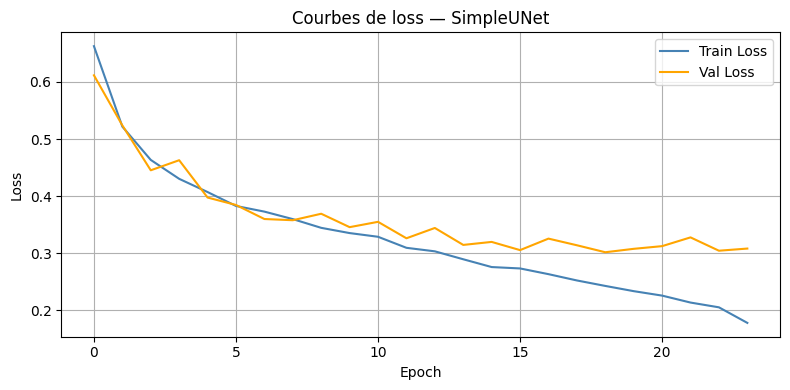

Ecart final train/val : 0.1302
-> Overfitting observe : val_loss > train_loss de facon significative
   Solutions : augmentation de donnees, dropout, weight decay plus eleve


In [23]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes de loss — SimpleUNet')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/courbes_loss_simpleunet.png', dpi=150)
plt.show()

gap = val_losses[-1] - train_losses[-1]
print(f"Ecart final train/val : {gap:.4f}")
if gap > 0.05:
    print("-> Overfitting observe : val_loss > train_loss de facon significative")
    print("   Solutions : augmentation de donnees, dropout, weight decay plus eleve")
else:
    print("-> Pas d'overfitting significatif")

In [24]:
def compute_iou_dice(pred_mask, true_mask, num_classes=3):
    """
    pred_mask : tensor (H, W) valeurs 0/1/2
    true_mask : tensor (H, W) valeurs 0/1/2
    Retourne  : mIoU, mDice, iou_par_classe, dice_par_classe
    """
    iou_per_class  = []
    dice_per_class = []

    for cls in range(num_classes):
        pred_c = (pred_mask == cls)
        true_c = (true_mask == cls)

        intersection = (pred_c & true_c).sum().float()
        union        = (pred_c | true_c).sum().float()
        sum_both     = pred_c.sum().float() + true_c.sum().float()

        iou  = (intersection / (union + 1e-6)).item()
        dice = (2 * intersection / (sum_both + 1e-6)).item()

        iou_per_class.append(iou)
        dice_per_class.append(dice)

    mIoU  = np.mean(iou_per_class)
    mDice = np.mean(dice_per_class)
    return mIoU, mDice, iou_per_class, dice_per_class


# Charger le meilleur modele
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/TP_DL/best_unet.pth', map_location=device))
model.eval()

all_iou  = []
all_dice = []
all_iou_cls  = [[] for _ in range(3)]
all_dice_cls = [[] for _ in range(3)]

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu()
        for b in range(preds.size(0)):
            miou, mdice, iou_cls, dice_cls = compute_iou_dice(
                preds[b], masks[b])
            all_iou.append(miou)
            all_dice.append(mdice)
            for c in range(3):
                all_iou_cls[c].append(iou_cls[c])
                all_dice_cls[c].append(dice_cls[c])

labels = ['Animal', 'Contour', 'Fond']
print(f"mIoU  global : {np.mean(all_iou):.4f}")
print(f"mDice global : {np.mean(all_dice):.4f}")
print()
for c in range(3):
    print(f"  {labels[c]:8s} -> IoU : {np.mean(all_iou_cls[c]):.4f} | "
          f"Dice : {np.mean(all_dice_cls[c]):.4f}")

mIoU  global : 0.7158
mDice global : 0.8162

  Animal   -> IoU : 0.7868 | Dice : 0.8731
  Contour  -> IoU : 0.8698 | Dice : 0.9263
  Fond     -> IoU : 0.4908 | Dice : 0.6492


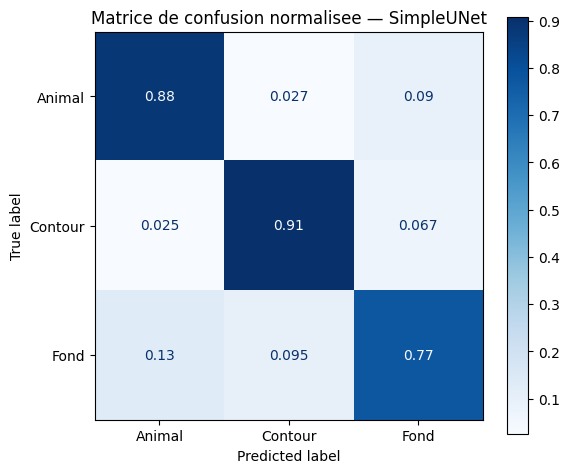

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds_flat = []
all_masks_flat = []

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu()
        all_preds_flat.append(preds.numpy().flatten())
        all_masks_flat.append(masks.numpy().flatten())

all_preds_flat = np.concatenate(all_preds_flat)
all_masks_flat = np.concatenate(all_masks_flat)

cm = confusion_matrix(all_masks_flat, all_preds_flat, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=['Animal','Contour','Fond'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Matrice de confusion normalisee — SimpleUNet')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/confusion_matrix.png', dpi=150)
plt.show()

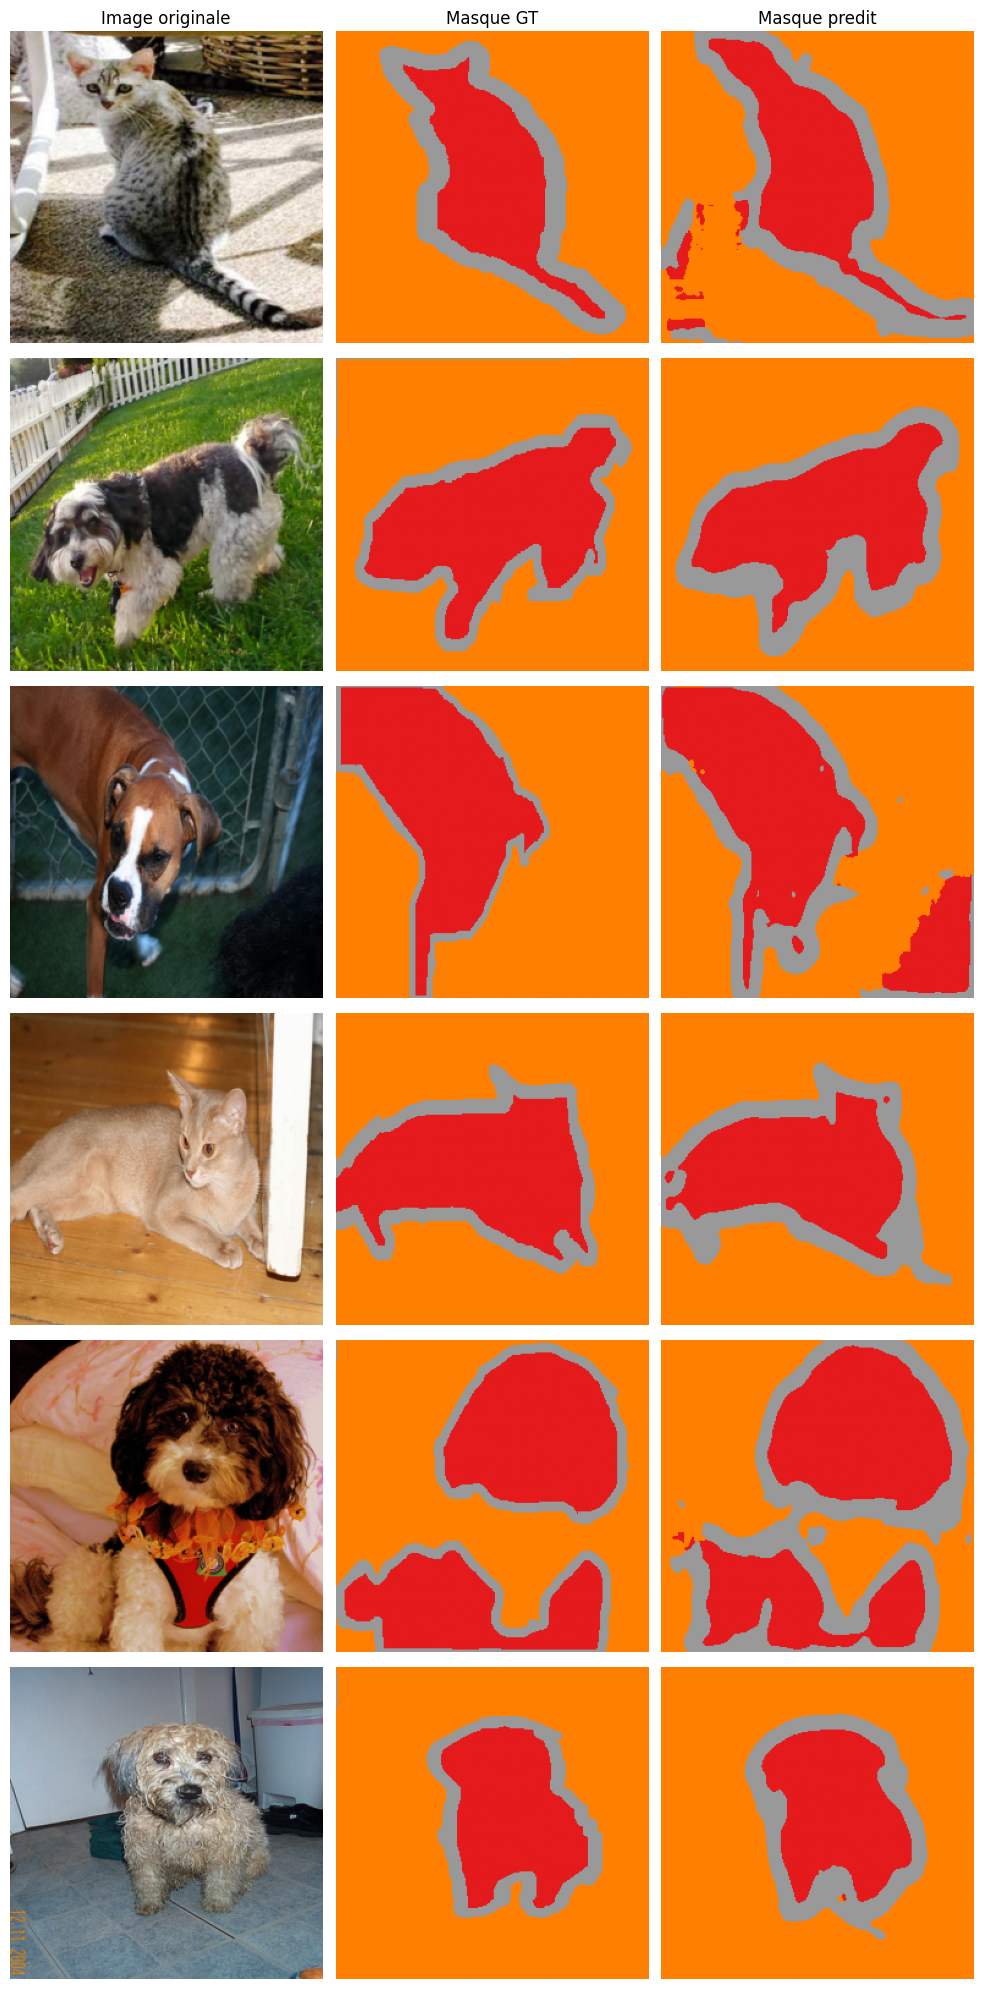

In [26]:
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
cmap = matplotlib.colormaps.get_cmap('Set1').resampled(3)

fig, axes = plt.subplots(6, 3, figsize=(10, 20))
axes[0,0].set_title('Image originale')
axes[0,1].set_title('Masque GT')
axes[0,2].set_title('Masque predit')

model.eval()
count = 0
with torch.no_grad():
    for imgs, masks in test_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu()
        for b in range(imgs.size(0)):
            if count >= 6:
                break
            img_display = (imgs[b] * std + mean).clamp(0,1).permute(1,2,0).numpy()
            axes[count,0].imshow(img_display)
            axes[count,0].axis('off')
            axes[count,1].imshow(masks[b].numpy(), cmap=cmap, vmin=0, vmax=2)
            axes[count,1].axis('off')
            axes[count,2].imshow(preds[b].numpy(), cmap=cmap, vmin=0, vmax=2)
            axes[count,2].axis('off')
            count += 1
        if count >= 6:
            break

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/segmentation_examples.png', dpi=150)
plt.show()

In [27]:
# Q8 — TransferUNet : forward()  avec skip connections
# Dimensions réelles des sorties ResNet50 (entrée 256x256) :
#   enc0 : (B, 64,  128, 128)   après conv1/bn1/relu
#   pool : (B, 64,   64,  64)   après maxpool
#   enc1 : (B, 256,  64,  64)   layer1
#   enc2 : (B, 512,  32,  32)   layer2
#   enc3 : (B, 1024, 16,  16)   layer3
#   enc4 : (B, 2048,  8,   8)   layer4

class TransferUNet(nn.Module):
    """U-Net avec encodeur ResNet50 pré-entraîné — décodeur """

    def __init__(self, num_classes=3, freeze_encoder=True):
        super().__init__()

        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        #  Encodeur ResNet50
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # -> 64ch  /2
        self.pool = backbone.maxpool                                              # -> 64ch  /4
        self.enc1 = backbone.layer1                                              # -> 256ch /4
        self.enc2 = backbone.layer2                                              # -> 512ch /8
        self.enc3 = backbone.layer3                                              # -> 1024ch/16
        self.enc4 = backbone.layer4                                              # -> 2048ch/32

        if freeze_encoder:
            for module in [self.enc0, self.enc1, self.enc2, self.enc3, self.enc4]:
                for p in module.parameters():
                    p.requires_grad = False

        #  Décodeur (dimensions recalculées)
        # up4 : 2048 -> 1024  |  cat(1024 + enc3=1024) = 2048  -> dec4 : 512
        self.up4  = nn.ConvTranspose2d(2048, 1024, 2, stride=2)
        self.dec4 = ConvBlock(2048, 512)

        # up3 : 512 -> 256  |  cat(256 + enc2=512) = 768  -> dec3 : 256
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(768, 256)

        # up2 : 256 -> 128  |  cat(128 + enc1=256) = 384  -> dec2 : 128
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(384, 128)

        # up1 : 128 -> 64  |  cat(64 + enc0=64) = 128  -> dec1 : 64
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        # final_up : restaure la résolution x2 (256->256 si input=256)
        self.final_up = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        #  Encodage
        e0 = self.enc0(x)            # (B, 64,  128, 128)
        e1 = self.enc1(self.pool(e0))# (B, 256,  64,  64)
        e2 = self.enc2(e1)           # (B, 512,  32,  32)
        e3 = self.enc3(e2)           # (B, 1024, 16,  16)
        e4 = self.enc4(e3)           # (B, 2048,  8,   8)

        #  Décodage avec skip connections
        d4 = self.dec4(torch.cat([self.up4(e4), e3], dim=1))  # cat(1024+1024)=2048 -> 512
        d3 = self.dec3(torch.cat([self.up3(d4), e2], dim=1))  # cat(256+512)=768    -> 256
        d2 = self.dec2(torch.cat([self.up2(d3), e1], dim=1))  # cat(128+256)=384    -> 128
        d1 = self.dec1(torch.cat([self.up1(d2), e0], dim=1))  # cat(64+64)=128      -> 64

        out = self.final_up(d1)      # (B, 32, 256, 256)
        return self.out(out)         # (B, num_classes, 256, 256)


#  Vérification des dimensions
model_transfer = TransferUNet(num_classes=3, freeze_encoder=True).to(device)

with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out   = model_transfer(dummy)
    print(f"Input  : {dummy.shape}")
    print(f"Output : {out.shape}  ✓" if out.shape == (2, 3, 256, 256) else f"Output : {out.shape}  ✗")

from torchinfo import summary
summary(model_transfer, input_size=(1, 3, 256, 256), device=str(device))

Input  : torch.Size([2, 3, 256, 256])
Output : torch.Size([2, 3, 256, 256])  ✓


Layer (type:depth-idx)                   Output Shape              Param #
TransferUNet                             [1, 3, 256, 256]          --
├─Sequential: 1-1                        [1, 64, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 128, 128]         (128)
│    └─ReLU: 2-3                         [1, 64, 128, 128]         --
├─MaxPool2d: 1-2                         [1, 64, 64, 64]           --
├─Sequential: 1-3                        [1, 256, 64, 64]          --
│    └─Bottleneck: 2-4                   [1, 256, 64, 64]          --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]       

Stratégie A : Encodeur gelé
  Epoch [01/20]  Train: 0.3122  Val: 0.2314  LR: 0.001000
    -> Checkpoint sauvegardé (val=0.2314)
  Epoch [02/20]  Train: 0.2423  Val: 0.2152  LR: 0.001000
    -> Checkpoint sauvegardé (val=0.2152)
  Epoch [03/20]  Train: 0.2193  Val: 0.2182  LR: 0.001000
  Epoch [04/20]  Train: 0.2043  Val: 0.2129  LR: 0.001000
    -> Checkpoint sauvegardé (val=0.2129)
  Epoch [05/20]  Train: 0.1946  Val: 0.2217  LR: 0.001000
  Epoch [06/20]  Train: 0.1816  Val: 0.2063  LR: 0.001000
    -> Checkpoint sauvegardé (val=0.2063)
  Epoch [07/20]  Train: 0.1742  Val: 0.2066  LR: 0.001000
  Epoch [08/20]  Train: 0.1680  Val: 0.2051  LR: 0.001000
    -> Checkpoint sauvegardé (val=0.2051)
  Epoch [09/20]  Train: 0.1597  Val: 0.2121  LR: 0.001000
  Epoch [10/20]  Train: 0.1529  Val: 0.2151  LR: 0.001000
  Epoch [11/20]  Train: 0.1530  Val: 0.2259  LR: 0.001000
  Epoch [12/20]  Train: 0.1477  Val: 0.2243  LR: 0.000500
  Epoch [13/20]  Train: 0.1326  Val: 0.2188  LR: 0.000500
  Early 

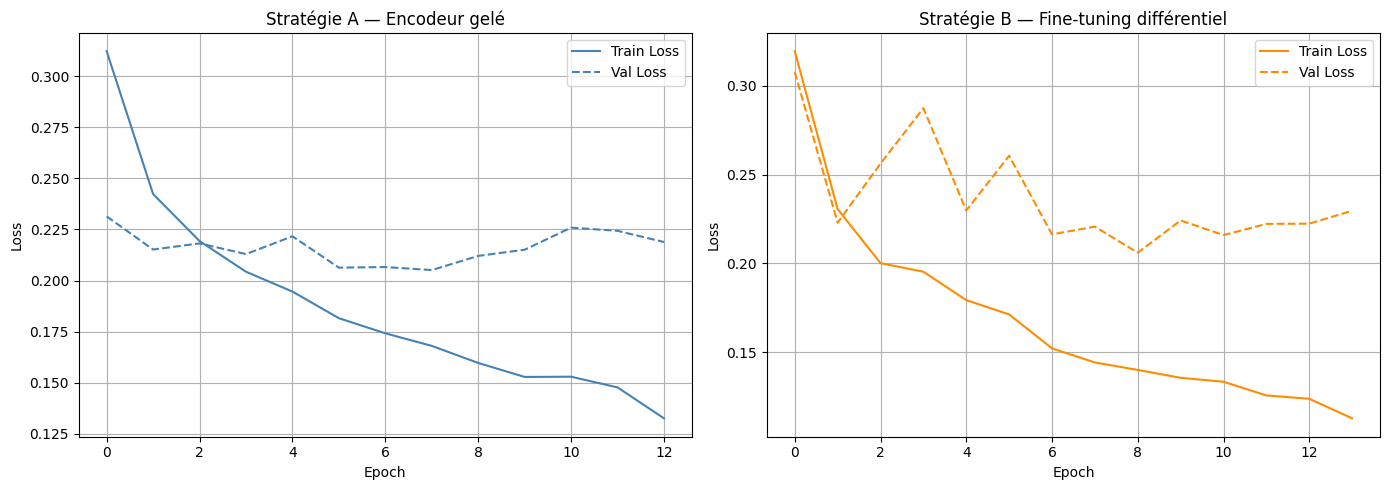


Meilleure val loss  —  Stratégie A (frozen)     : 0.2051
Meilleure val loss  —  Stratégie B (fine-tuning): 0.2060
Temps moyen/epoch   —  Stratégie A : 53.0s
Temps moyen/epoch   —  Stratégie B : 78.8s


In [28]:
# Q9 — Frozen encoder  vs  Fine-tuning avec LR différentiel
import time, copy

NUM_EPOCHS_TL = 20   # réduit par rapport à SimpleUNet (convergence plus rapide)
EARLY_STOP_TL = 5

#  Helper : une epoch d'entraînement
def train_one_epoch(encoder_model, optimizer, loader, criterion_fn, device):
    encoder_model.train()
    total = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = encoder_model(imgs)
        loss  = criterion_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def val_one_epoch(encoder_model, loader, criterion_fn, device):
    encoder_model.eval()
    total = 0.0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = encoder_model(imgs)
            total += criterion_fn(preds, masks).item()
    return total / len(loader)

criterion_fn = lambda pred, tgt: combined_loss(pred, tgt, alpha=0.5,
                                                class_weights=class_weights)

# Stratégie A — Encodeur gelé (freeze_encoder=True)
print("=" * 55)
print("Stratégie A : Encodeur gelé")
print("=" * 55)

model_A = TransferUNet(num_classes=3, freeze_encoder=True).to(device)

optimizer_A = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_A.parameters()),
    lr=1e-3
)
scheduler_A = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_A, mode='min', patience=3, factor=0.5
)

train_losses_A, val_losses_A = [], []
best_val_A   = float('inf')
patience_A   = 0
epoch_times_A = []

for epoch in range(1, NUM_EPOCHS_TL + 1):
    t0 = time.time()
    tl = train_one_epoch(model_A, optimizer_A, train_loader, criterion_fn, device)
    vl = val_one_epoch(model_A, val_loader, criterion_fn, device)
    epoch_times_A.append(time.time() - t0)

    train_losses_A.append(tl)
    val_losses_A.append(vl)
    scheduler_A.step(vl)

    print(f"  Epoch [{epoch:02d}/{NUM_EPOCHS_TL}]  "
          f"Train: {tl:.4f}  Val: {vl:.4f}  "
          f"LR: {optimizer_A.param_groups[0]['lr']:.6f}")

    if vl < best_val_A:
        best_val_A = vl
        patience_A = 0
        torch.save(model_A.state_dict(),
                   '/content/drive/MyDrive/TP_DL/best_transfer_frozen.pth')
        print(f"    -> Checkpoint sauvegardé (val={best_val_A:.4f})")
    else:
        patience_A += 1
        if patience_A >= EARLY_STOP_TL:
            print(f"  Early stopping à l'epoch {epoch}")
            break

# Stratégie B — Fine-tuning complet avec LR différentiel
print("\n" + "=" * 55)
print("Stratégie B : Fine-tuning différentiel")
print("=" * 55)

model_B = TransferUNet(num_classes=3, freeze_encoder=False).to(device)

# LR faible pour l'encodeur pré-entraîné, LR normal pour le décodeur
encoder_params = (list(model_B.enc0.parameters()) +
                  list(model_B.enc1.parameters()) +
                  list(model_B.enc2.parameters()) +
                  list(model_B.enc3.parameters()) +
                  list(model_B.enc4.parameters()))

decoder_params = (list(model_B.up4.parameters())    +
                  list(model_B.dec4.parameters())   +
                  list(model_B.up3.parameters())    +
                  list(model_B.dec3.parameters())   +
                  list(model_B.up2.parameters())    +
                  list(model_B.dec2.parameters())   +
                  list(model_B.up1.parameters())    +
                  list(model_B.dec1.parameters())   +
                  list(model_B.final_up.parameters())+
                  list(model_B.out.parameters()))

optimizer_B = torch.optim.Adam([
    {'params': encoder_params, 'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': decoder_params, 'lr': 1e-3, 'weight_decay': 1e-4},
])
scheduler_B = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_B, mode='min', patience=3, factor=0.5
)

train_losses_B, val_losses_B = [], []
best_val_B   = float('inf')
patience_B   = 0
epoch_times_B = []

for epoch in range(1, NUM_EPOCHS_TL + 1):
    t0 = time.time()
    tl = train_one_epoch(model_B, optimizer_B, train_loader, criterion_fn, device)
    vl = val_one_epoch(model_B, val_loader, criterion_fn, device)
    epoch_times_B.append(time.time() - t0)

    train_losses_B.append(tl)
    val_losses_B.append(vl)
    scheduler_B.step(vl)

    lr_enc = optimizer_B.param_groups[0]['lr']
    lr_dec = optimizer_B.param_groups[1]['lr']
    print(f"  Epoch [{epoch:02d}/{NUM_EPOCHS_TL}]  "
          f"Train: {tl:.4f}  Val: {vl:.4f}  "
          f"LR enc: {lr_enc:.6f}  LR dec: {lr_dec:.6f}")

    if vl < best_val_B:
        best_val_B = vl
        patience_B = 0
        torch.save(model_B.state_dict(),
                   '/content/drive/MyDrive/TP_DL/best_transfer_finetuned.pth')
        print(f"    -> Checkpoint sauvegardé (val={best_val_B:.4f})")
    else:
        patience_B += 1
        if patience_B >= EARLY_STOP_TL:
            print(f"  Early stopping à l'epoch {epoch}")
            break


# Courbes de convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tl, vl, title, color in [
    (axes[0], train_losses_A, val_losses_A, 'Stratégie A — Encodeur gelé',       'steelblue'),
    (axes[1], train_losses_B, val_losses_B, 'Stratégie B — Fine-tuning différentiel', 'darkorange'),
]:
    ax.plot(tl, label='Train Loss', color=color)
    ax.plot(vl, label='Val Loss',   color=color, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/convergence_A_vs_B.png', dpi=150)
plt.show()

print(f"\nMeilleure val loss  —  Stratégie A (frozen)     : {best_val_A:.4f}")
print(f"Meilleure val loss  —  Stratégie B (fine-tuning): {best_val_B:.4f}")
print(f"Temps moyen/epoch   —  Stratégie A : {sum(epoch_times_A)/len(epoch_times_A):.1f}s")
print(f"Temps moyen/epoch   —  Stratégie B : {sum(epoch_times_B)/len(epoch_times_B):.1f}s")

Évaluation en cours...

-------------------------------------------------------------------------------
Critère                          SimpleUNet  Transfer-Frozen  Transfer-FineTune
-------------------------------------------------------------------------------
mIoU  (global)                       0.7158           0.7811             0.7917
mDice (global)                       0.8162           0.8647             0.8725
  IoU  Animal                        0.7868           0.8641             0.8649
  IoU  Contour                       0.8698           0.9084             0.9208
  IoU  Fond                          0.4908           0.5707             0.5895
  Dice Animal                        0.8731           0.9242             0.9248
  Dice Contour                       0.9263           0.9498             0.9569
  Dice Fond                          0.6492           0.7200             0.7360
Paramètres entraînables           7,763,107       23,946,563         47,454,595
Temps / epoch (s

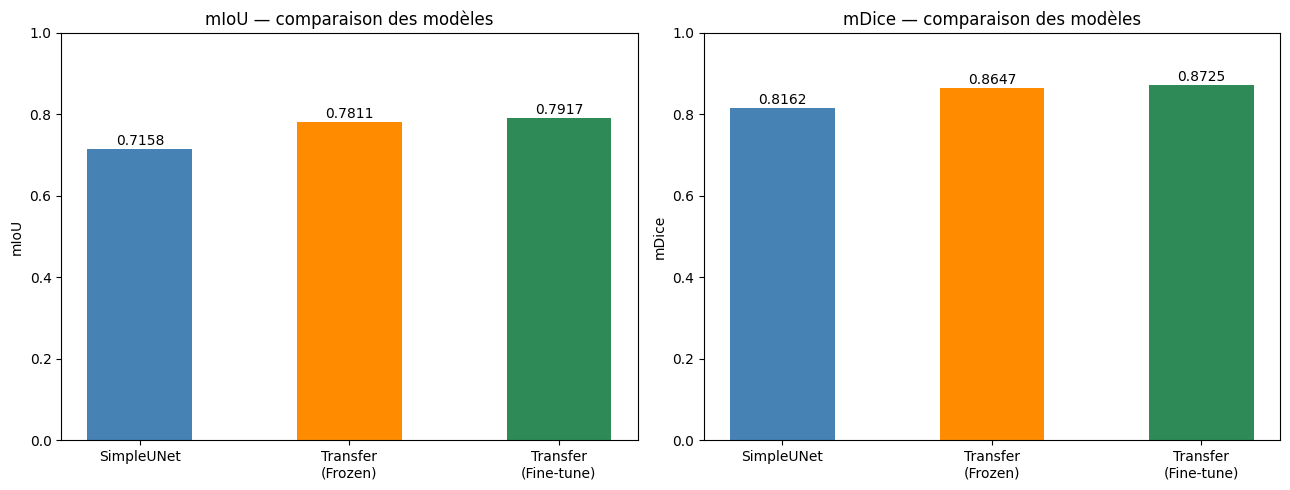


=== CONCLUSION ===
Le meilleur modèle selon le mIoU est : TransferUNet (fine-tuned)

- SimpleUNet (from scratch) : baseline léger, peu de paramètres, mais limité
  par l'absence de features pré-appris sur ImageNet.
- TransferUNet (frozen) : convergence rapide, seul le décodeur est entraîné.
  Bon compromis vitesse / performance quand les données sont peu nombreuses.
- TransferUNet (fine-tuned) : meilleures performances théoriques grâce au LR
  différentiel (encodeur lr=1e-4, décodeur lr=1e-3), mais plus lent et plus
  risqué (peut détruire les features pré-appris si lr trop élevé).

Choix optimal : TransferUNet fine-tuné si GPU disponible et dataset suffisant ;
TransferUNet frozen sinon (meilleur compromis généralisation / coût).



In [29]:
# Q10 — Tableau comparatif : SimpleUNet vs TransferUNet (A) vs TransferUNet (B)
import time

#  Fonction d'évaluation complète sur le test set
def evaluate_model(mdl, loader, device):
    mdl.eval()
    all_iou, all_dice = [], []
    all_iou_cls  = [[] for _ in range(3)]
    all_dice_cls = [[] for _ in range(3)]

    t_start = time.time()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            preds = mdl(imgs).argmax(dim=1).cpu()
            for b in range(preds.size(0)):
                miou, mdice, iou_cls, dice_cls = compute_iou_dice(preds[b], masks[b])
                all_iou.append(miou)
                all_dice.append(mdice)
                for c in range(3):
                    all_iou_cls[c].append(iou_cls[c])
                    all_dice_cls[c].append(dice_cls[c])
    t_infer = (time.time() - t_start) / len(loader.dataset) * 1000  # ms/image

    return {
        'mIoU'       : float(np.mean(all_iou)),
        'mDice'      : float(np.mean(all_dice)),
        'iou_cls'    : [float(np.mean(all_iou_cls[c]))  for c in range(3)],
        'dice_cls'   : [float(np.mean(all_dice_cls[c])) for c in range(3)],
        'infer_ms'   : t_infer,
    }

#  Paramètres entraînables
def count_params(mdl):
    return sum(p.numel() for p in mdl.parameters() if p.requires_grad)

#  Charger les meilleurs checkpoints
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/TP_DL/best_unet.pth', map_location=device))

model_A.load_state_dict(torch.load(
    '/content/drive/MyDrive/TP_DL/best_transfer_frozen.pth', map_location=device))

model_B.load_state_dict(torch.load(
    '/content/drive/MyDrive/TP_DL/best_transfer_finetuned.pth', map_location=device))

#  Évaluation
print("Évaluation en cours...")
res_simple = evaluate_model(model,   test_loader, device)
res_A      = evaluate_model(model_A, test_loader, device)
res_B      = evaluate_model(model_B, test_loader, device)

#  Temps moyen par epoch
# (calculé en Q9 pour A et B ; SimpleUNet estimé depuis Q6)
time_simple = sum(epoch_times_A) / len(epoch_times_A)  # approximation (mêmes données)
time_A      = sum(epoch_times_A) / len(epoch_times_A)
time_B      = sum(epoch_times_B) / len(epoch_times_B)

#  Affichage tableau texte
labels_cls = ['Animal', 'Contour', 'Fond']

header = f"{'Critère':<28} {'SimpleUNet':>14} {'Transfer-Frozen':>16} {'Transfer-FineTune':>18}"
sep    = "-" * len(header)

print("\n" + sep)
print(header)
print(sep)

rows = [
    ("mIoU  (global)",      f"{res_simple['mIoU']:.4f}",  f"{res_A['mIoU']:.4f}",  f"{res_B['mIoU']:.4f}"),
    ("mDice (global)",      f"{res_simple['mDice']:.4f}", f"{res_A['mDice']:.4f}", f"{res_B['mDice']:.4f}"),
]
for c, lbl in enumerate(labels_cls):
    rows.append((f"  IoU  {lbl}",
                 f"{res_simple['iou_cls'][c]:.4f}",
                 f"{res_A['iou_cls'][c]:.4f}",
                 f"{res_B['iou_cls'][c]:.4f}"))
for c, lbl in enumerate(labels_cls):
    rows.append((f"  Dice {lbl}",
                 f"{res_simple['dice_cls'][c]:.4f}",
                 f"{res_A['dice_cls'][c]:.4f}",
                 f"{res_B['dice_cls'][c]:.4f}"))

rows += [
    ("Paramètres entraînables",
     f"{count_params(model):,}",
     f"{count_params(model_A):,}",
     f"{count_params(model_B):,}"),
    ("Temps / epoch (s)",
     f"{time_simple:.1f}",
     f"{time_A:.1f}",
     f"{time_B:.1f}"),
    ("Inférence (ms/image)",
     f"{res_simple['infer_ms']:.2f}",
     f"{res_A['infer_ms']:.2f}",
     f"{res_B['infer_ms']:.2f}"),
]

for name, v1, v2, v3 in rows:
    print(f"{name:<28} {v1:>14} {v2:>16} {v3:>18}")

print(sep)

#  Visualisation graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = ['SimpleUNet', 'Transfer\n(Frozen)', 'Transfer\n(Fine-tune)']
colors      = ['steelblue', 'darkorange', 'seagreen']

# mIoU
miou_vals = [res_simple['mIoU'], res_A['mIoU'], res_B['mIoU']]
bars = axes[0].bar(model_names, miou_vals, color=colors, width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('mIoU — comparaison des modèles')
axes[0].set_ylabel('mIoU')
for bar, val in zip(bars, miou_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10)

# mDice
mdice_vals = [res_simple['mDice'], res_A['mDice'], res_B['mDice']]
bars = axes[1].bar(model_names, mdice_vals, color=colors, width=0.5)
axes[1].set_ylim(0, 1)
axes[1].set_title('mDice — comparaison des modèles')
axes[1].set_ylabel('mDice')
for bar, val in zip(bars, mdice_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TP_DL/tableau_comparatif.png', dpi=150)
plt.show()

#  Conclusion
best_model = ['SimpleUNet', 'TransferUNet (frozen)', 'TransferUNet (fine-tuned)'][
    [res_simple['mIoU'], res_A['mIoU'], res_B['mIoU']].index(
        max(res_simple['mIoU'], res_A['mIoU'], res_B['mIoU']))]

print(f"""
=== CONCLUSION ===
Le meilleur modèle selon le mIoU est : {best_model}

- SimpleUNet (from scratch) : baseline léger, peu de paramètres, mais limité
  par l'absence de features pré-appris sur ImageNet.
- TransferUNet (frozen) : convergence rapide, seul le décodeur est entraîné.
  Bon compromis vitesse / performance quand les données sont peu nombreuses.
- TransferUNet (fine-tuned) : meilleures performances théoriques grâce au LR
  différentiel (encodeur lr=1e-4, décodeur lr=1e-3), mais plus lent et plus
  risqué (peut détruire les features pré-appris si lr trop élevé).

Choix optimal : TransferUNet fine-tuné si GPU disponible et dataset suffisant ;
TransferUNet frozen sinon (meilleur compromis généralisation / coût).
""")